 **Project-**ML**+NLP= Amazon Reviews-sentiment analysis.**:

# New Section

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
df=pd.read_csv('/content/drive/MyDrive/Programming.folder/ML+NLP=Amazon Reviews sentiment analysis peoject.📈/Amazon-Product-Reviews - Amazon Product Review.csv')
df

,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date,sentiment
0,US,11555559,R1QXC7AHHJBQ3O,B00IKPX4GY,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,0,0,N,Y,Five Stars,Great love it,2015-08-31,1
1,US,31469372,R175VSRV6ZETOP,B00IKPYKWG,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,3,0,0,N,N,Lots of ads Slow processing speed Occasionally...,Lots of ads<br />Slow processing speed<br />Oc...,2015-08-31,0
2,US,26843895,R2HRFF78MWGY19,B00IKPW0UA,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,0,0,N,Y,Well thought out device,Excellent unit. The versatility of this table...,2015-08-31,1
3,US,19844868,R8Q39WPKYVSTX,B00LCHSHMS,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,4,0,0,N,N,Not all apps/games we were looking forward to ...,I bought this on Amazon Prime so I ended up bu...,2015-08-31,1
4,US,1189852,R3RL4C8YP2ZCJL,B00IKPZ5V6,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,0,0,N,Y,Five Stars,All Amazon products continue to meet my expect...,2015-08-31,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30841,US,44834233,R366C7ARIWLN7R,B00IKPW0UA,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,3720,3875,N,Y,A great upgrade for me from an older Kindle Fire!,[[VIDEOID:moP3B6GS5RL8LY]]I purchased the orig...,2014-10-03,1
30842,US,13376158,R35PL0AOCUXLU9,B00IKPYKWG,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,2716,2849,N,Y,Great Value for $139,I'm writing this review with the benefit of be...,2014-10-03,1
30843,US,40485963,R18ZJVY86AUFII,B00KC6XV58,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,1525,1629,N,Y,Even grandma has it figured out!,"I purchased this Kindle for my grandma, becaus...",2014-10-03,1
30844,US,33485035,R36QVLQXMCZRSJ,B00IKPYKWG,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,4,143,163,N,Y,The Honda Accord of Tablets,I bought my tablet Fire HD 7 at Best Buy on th...,2014-10-03,1


In [3]:
df.shape

(30846, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30846 entries, 0 to 30845
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   marketplace        30846 non-null  object
 1   customer_id        30846 non-null  int64 
 2   review_id          30846 non-null  object
 3   product_id         30846 non-null  object
 4   product_parent     30846 non-null  int64 
 5   product_title      30846 non-null  object
 6   product_category   30846 non-null  object
 7   star_rating        30846 non-null  int64 
 8   helpful_votes      30846 non-null  int64 
 9   total_votes        30846 non-null  int64 
 10  vine               30846 non-null  object
 11  verified_purchase  30846 non-null  object
 12  review_headline    30844 non-null  object
 13  review_body        30842 non-null  object
 14  review_date        30846 non-null  object
 15  sentiment          30846 non-null  int64 
dtypes: int64(6), object(10)
memory usage: 3.

In [5]:
df.columns

Index(['marketplace', 'customer_id', 'review_id', 'product_id',
       'product_parent', 'product_title', 'product_category', 'star_rating',
       'helpful_votes', 'total_votes', 'vine', 'verified_purchase',
       'review_headline', 'review_body', 'review_date', 'sentiment'],
      dtype='object')

In [6]:
df.isnull().sum()

,0
marketplace,0
customer_id,0
review_id,0
product_id,0
product_parent,0
product_title,0
product_category,0
star_rating,0
helpful_votes,0
total_votes,0


In [7]:
df['sentiment'].value_counts()

,count
sentiment,
1,25767
0,5079


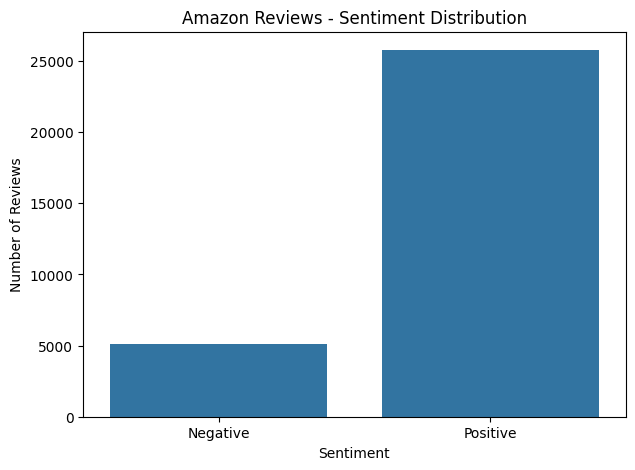

In [8]:

plt.figure(figsize=(7, 5))

ax = sns.countplot( data=df, x='sentiment',order=[0, 1])

ax.set_xticklabels(['Negative', 'Positive'])

plt.title('Amazon Reviews - Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

plt.show()

In [9]:
df['star_rating'].value_counts().sort_index()

,count
star_rating,
1,1708
2,1155
3,2216
4,5748
5,20019


Text(0, 0.5, 'Number of Reviews')

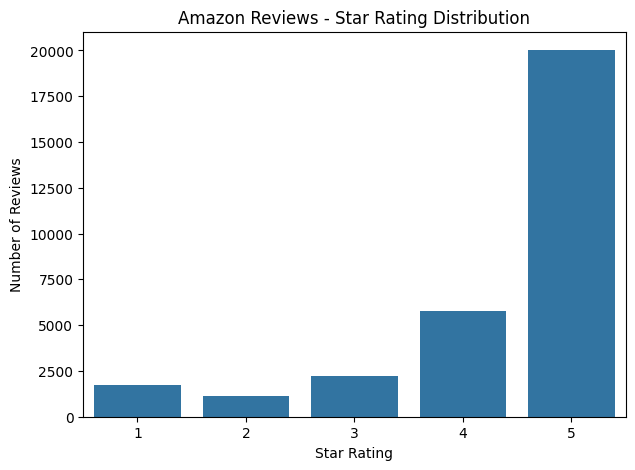

In [10]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x='star_rating',
    order=[1, 2, 3, 4, 5]
)

plt.title('Amazon Reviews - Star Rating Distribution')
plt.xlabel('Star Rating')
plt.ylabel('Number of Reviews')


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.shape

(30846, 16)

In [14]:
df[['review_headline', 'review_body', 'star_rating', 'sentiment']].head(10)

,review_headline,review_body,star_rating,sentiment
0,Five Stars,Great love it,5,1
1,Lots of ads Slow processing speed Occasionally...,Lots of ads<br />Slow processing speed<br />Oc...,3,0
2,Well thought out device,Excellent unit. The versatility of this table...,5,1
3,Not all apps/games we were looking forward to ...,I bought this on Amazon Prime so I ended up bu...,4,1
4,Five Stars,All Amazon products continue to meet my expect...,5,1
5,Four Stars,Good product. I like it 😀,4,1
6,Not a bad product. Simple. Works well. Nothing...,This kindle works well but the battery goes de...,4,1
7,Five Stars,"I really enjoy my new kindle, it is easy to us...",5,1
8,"Everything works great, the menu system is awful",It's what I wanted and performs perfectly. Eve...,4,1
9,Like looks and,Made well. Like looks and style,5,1


In [15]:

df = df.dropna(subset=['review_body'])

In [16]:
df = df.drop_duplicates()

In [17]:
df.shape

(30842, 16)

In [18]:
print(df.isnull().sum())

marketplace          0
customer_id          0
review_id            0
product_id           0
product_parent       0
product_title        0
product_category     0
star_rating          0
helpful_votes        0
total_votes          0
vine                 0
verified_purchase    0
review_headline      2
review_body          0
review_date          0
sentiment            0
dtype: int64


In [19]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [20]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [21]:

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()

    # Remove HTML tags
    text = re.sub(r'<br\s*/?>', ' ', text)

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization and stopword removal
    words = text.split()
    words = [word for word in words if word not in stop_words]

    # Lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]

    return ' '.join(words)


In [22]:
df['cleaned_review'] = df['review_body'].apply(clean_text)

In [23]:
df[['review_body', 'cleaned_review']].head(10)

,review_body,cleaned_review
0,Great love it,great love
1,Lots of ads<br />Slow processing speed<br />Oc...,lot ad slow processing speed occasionally shut...
2,Excellent unit. The versatility of this table...,excellent unit versatility tablet besides comp...
3,I bought this on Amazon Prime so I ended up bu...,bought amazon prime ended buying gb one camera...
4,All Amazon products continue to meet my expect...,amazon product continue meet expectation
5,Good product. I like it 😀,good product like
6,This kindle works well but the battery goes de...,kindle work well battery go dead quickly expec...
7,"I really enjoy my new kindle, it is easy to us...",really enjoy new kindle easy use offer plenty ...
8,It's what I wanted and performs perfectly. Eve...,wanted performs perfectly everything work grea...
9,Made well. Like looks and style,made well like look style


In [24]:
from sklearn.model_selection import train_test_split

X = df['cleaned_review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (24673,)
Testing data: (6169,)


In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (24673, 5000)
Testing TF-IDF shape: (6169, 5000)


In [26]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [27]:
y_pred = model.predict(X_test_tfidf)

In [28]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9050089155454693


In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.58      0.67      1016
           1       0.92      0.97      0.94      5153

    accuracy                           0.91      6169
   macro avg       0.85      0.77      0.81      6169
weighted avg       0.90      0.91      0.90      6169



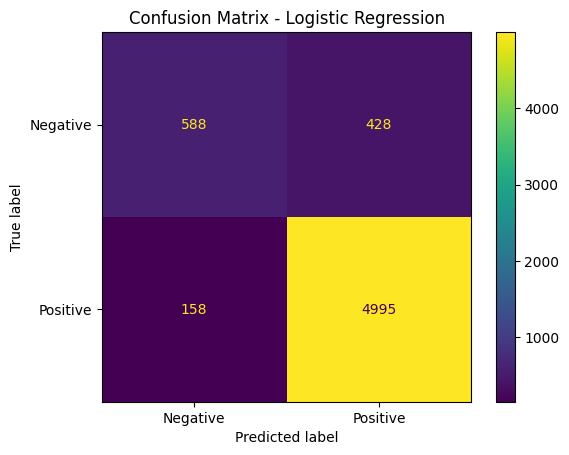

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative', 'Positive']
)

disp.plot()
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

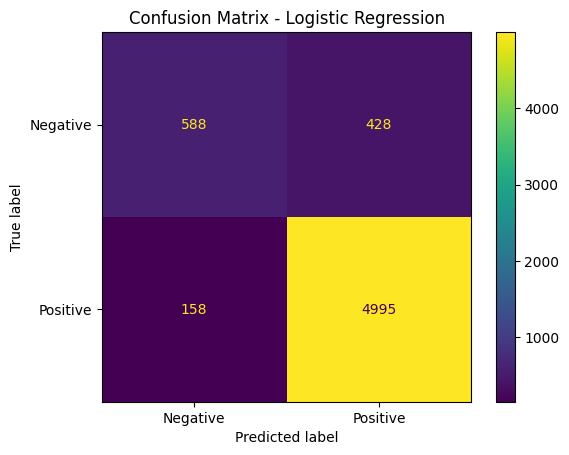

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative', 'Positive']
)

disp.plot()
plt.title('Confusion Matrix - Logistic Regression')
plt.show()


In [32]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Create Naive Bayes model
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train_tfidf, y_train)

# Predict on test data
y_pred_nb = nb_model.predict(X_test_tfidf)

# Accuracy
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", accuracy_nb)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.8956070675960447

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.51      0.62      1016
           1       0.91      0.97      0.94      5153

    accuracy                           0.90      6169
   macro avg       0.84      0.74      0.78      6169
weighted avg       0.89      0.90      0.89      6169



In [33]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

# Create Linear SVM model
svm_model = LinearSVC()

# Train the model
svm_model.fit(X_train_tfidf, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test_tfidf)

# Accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("Linear SVM Accuracy:", accuracy_svm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

Linear SVM Accuracy: 0.9043605122386125

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.64      0.69      1016
           1       0.93      0.96      0.94      5153

    accuracy                           0.90      6169
   macro avg       0.84      0.80      0.82      6169
weighted avg       0.90      0.90      0.90      6169



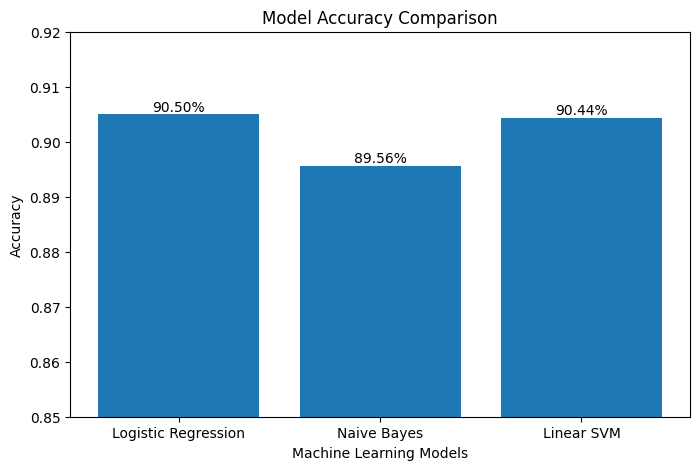

In [34]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Naive Bayes', 'Linear SVM']
accuracies = [accuracy_score(y_test, y_pred),
              accuracy_nb,
              accuracy_svm]

plt.figure(figsize=(8, 5))

bars = plt.bar(models, accuracies)

plt.title('Model Accuracy Comparison')
plt.xlabel('Machine Learning Models')
plt.ylabel('Accuracy')

plt.ylim(0.85, 0.92)

for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{acc*100:.2f}%',
        ha='center',
        va='bottom'
    )

plt.show()

In [35]:
def predict_sentiment(review):
    # Clean the review
    cleaned_review = clean_text(review)

    # Convert text into TF-IDF
    review_tfidf = tfidf.transform([cleaned_review])

    # Predict sentiment
    prediction = svm_model.predict(review_tfidf)[0]

    if prediction == 1:
        return "Positive 😊"
    else:
        return "Negative 😞"

In [36]:
review = "I really love this product. The quality is excellent."

result = predict_sentiment(review)

print("Review:", review)
print("Predicted Sentiment:", result)

Review: I really love this product. The quality is excellent.
Predicted Sentiment: Positive 😊


In [37]:
review = "Very bad product. The quality is poor and I am disappointed."

result = predict_sentiment(review)

print("Review:", review)
print("Predicted Sentiment:", result)

Review: Very bad product. The quality is poor and I am disappointed.
Predicted Sentiment: Negative 😞


In [ ]:
review = input("Enter your Amazon review: ")

result = predict_sentiment(review)

print("\nReview:", review)
print("Predicted Sentiment:", result)

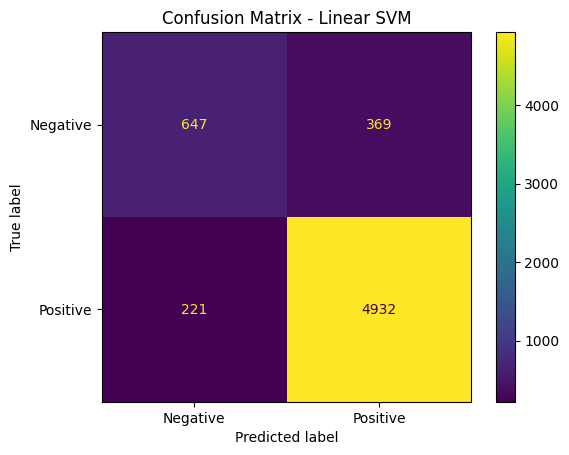

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=['Negative', 'Positive']
)

disp.plot()

plt.title('Confusion Matrix - Linear SVM')
plt.show()

Conclusion:
This project developed an Amazon Customer Review Sentiment Analysis system using Natural Language Processing and Machine Learning. The reviews were cleaned and preprocessed using NLP techniques and converted into numerical features using TF-IDF. Logistic Regression, Naive Bayes, and Linear SVM models were trained and evaluated. Linear SVM achieved 90.44% accuracy with a 0.69 F1-score for negative reviews and 0.94 F1-score for positive reviews. The final system can predict the sentiment of new customer reviews as Positive or Negative.